# Resolución de la dinámica en forma simbólica

Se presenta un algoritmo simple para resolver la dinámica por Euler Lagrange
Luego se aplica a doble péndulo y se muestra el resultado de la integración numérica para calcular la trayectoria en el espacio de operación 

In [ ]:
# Para correr en Colab
%pip install roboticstoolbox-python
%pip install numpy==1.26.4 --force-reinstall

# Nota importante: da error porque un montón de bibliotecas de Colab dependen de numpy 2, 
# pero como no se utilizan no importa. 
#
# Cuando termina de ejecutarse la celda, pide reiniciar el kernel (aparece un botón bien evidente)
# Luego de reiniciar correr las celdas siguientes

In [38]:
import numpy as np
import sympy as sp
import roboticstoolbox as rtb
from matplotlib import pyplot as plt
import matplotlib
%matplotlib inline

print(matplotlib.get_backend())


inline


## Cinemática simbólica

Método aplicable a cualquier robot serie

In [125]:
def fkine_symbolic(DH):
    """
    Cinemática directa con parámetros DH distales.
    
    Parámetros:
    -----------
    DH : lista de diccionarios
        Cada elemento corresponde a {'a':..., 'd':..., 'alpha':..., 'theta':..., 'joint_type':... }.
        Los valores pueden ser constantes o simbólicos.
        joint_type : tipo de articulación ('r' o 'p').

    Retorna:
    --------
    q : vector de variables articulares simbólicas
    A_list : lista con matrices homogéneas A_i (de i-1 a i)
    W_list : lista con matrices homogéneas acumuladas (0 hasta i)
    """
    
    N_axis = len(DH)
    
    # Defino variables articulares simbólicas
    q = sp.symbols(f'q1:{N_axis+1}', real=True)
            
    # Construyo matrices A_i
    A_list = []
    W_list = []
    
    for i in range(0,N_axis):
        theta = DH[i].get('theta', sp.symbols(f"theta{i+1}", real=True))
        d     = DH[i].get('d',     sp.symbols(f"d{i+1}", real=True))
        a     = DH[i].get('a',     sp.symbols(f"a{i+1}", real=True))
        alpha = DH[i].get('alpha', sp.symbols(f"alpha{i+1}", real=True))

        # Sustituyo según tipo de articulación
        if DH[i].get('joint_type') == 'r':   # rotacional → theta = q[i]
            theta = q[i]
        elif DH[i].get('joint_type') == 'p': # prismática → d = q[i]
            d = q[i]

        A = sp.Matrix([
            [sp.cos(theta), -sp.sin(theta)*sp.cos(alpha),  sp.sin(theta)*sp.sin(alpha), a*sp.cos(theta)],
            [sp.sin(theta),  sp.cos(theta)*sp.cos(alpha), -sp.cos(theta)*sp.sin(alpha), a*sp.sin(theta)],
            [0,                      sp.sin(alpha),                      sp.cos(alpha),               d],
            [0,                      0,                                      0,                       1]
        ])
        A = sp.simplify(A)
        A = sp.nsimplify(A, tolerance=1e-12)
        A_list.append(A)
        
        if i == 0:
            W_list.append(A)
        else:
            W_list.append(sp.simplify(W_list[-1]*A))
    
    return A_list, W_list, q


In [130]:
def inv_SE3(T):
    R = T[:3, :3]
    p = T[:3, 3]

    R_T = R.T
    p_new = -R_T @ p

    T_inv = sp.eye(4)
    T_inv[:3, :3] = R_T
    T_inv[:3, 3] = p_new

    return T_inv

def calcAij(A, i, j):
        """
        Calcula la transformación entre i y j usando lista de matrices A_i.

        Parámetros:
            A : list of sympy.Matrix (A[0] = A1 en MATLAB)
            i, j : índices (base 0)
            simplify_result : bool (opcional, evitar por defecto)

        Retorna:
            Aij : sympy.Matrix
        """

        # convertir a índices Python
        i -= 1
        j -= 1

        # Determinar sentido
        if i < j:
            ss = -1
            k_idx = list(range(i, j+1))
        elif i > j:
            ss = 1
            k_idx = list(range(j, i+1))
        else:
            return sp.eye(4)

        # Producto
        Aij = sp.eye(4)

        for k in range(1, len(k_idx)):
            Aij = Aij @ A[k_idx[k]]

        # Inversión si corresponde
        if ss == -1:
            Aij = inv_SE3(Aij)

        Aij = sp.simplify(Aij) 
        return Aij


def jacobian_symbolic(DH, A, oJv, pJv, pJw):
    """
    Jacobiano simbólico 

    Parámetros:
        DH : parámetros cinemáticos del robot
        A : lista de matrices homogéneas (A[0] = A1)
        oJv, pJv, pJw : índices de frames (base 0)
    """

    J = sp.zeros(6, len(DH))

    for iq in range(len(DH)):

        is_revolute = (DH[iq].get('joint_type') == 'r')

        Aojv = calcAij(A, oJv, iq)
        Apjv = calcAij(A, pJv, iq)
        Apjw = calcAij(A, pJw, iq)

        # --- bloque lineal ---
        p = Aojv[:3, 3]

        for ic in range(3):
            if is_revolute:
                r = Apjv[:3, ic]
                v_aux = p.cross(r)
            else:
                v_aux = Apjw[:3, ic]

            J[ic, iq] = sp.simplify(v_aux[2])

        # --- bloque angular ---
        for ic in range(3):
            if is_revolute:
                r = Apjw[:3, ic]
                J[ic+3, iq] = sp.simplify(r[2])
            else:
                J[ic+3, iq] = 0    

    return J

## Dinámica simbólica

Método aplicable a cualquier robot serie

In [ ]:
def dynamics_lagrange(DH, A_list, W_list, q, g_vec,dyn_params, Kmethod='trace'):
    """
    Calcula las matrices dinámicas M, C y el vector G de un robot genérico 
    usando el formalismo de Lagrange y los parámetros dinámicos.

    Parámetros:
    -----------
    DH : 
    A_list: 
    W_list : list of sympy.Matrix
        Lista de transformaciones homogéneas acumuladas (de la base hasta cada eslabón).
    q : list of sympy.Symbol
        Vector de coordenadas articulares.
    g_vec : sympy.Matrix
        Vector de gravedad (ej: sp.Matrix([0, -9.81, 0]) para gravedad en -y).
    
    Retorna:
    --------
    M : sympy.Matrix
        Matriz de inercia.
    C : sympy.Matrix
        Matriz centrífuga/coriolis.
    G : sympy.Matrix
        Vector de gravedad.
    """
    
    N_axis = len(q)

    # Variables simbólicas: velocidades y aceleraciones
    q_p  = sp.symbols(f'qp_1:{N_axis+1}', real=True)
    q_2p = sp.symbols(f'q2p_1:{N_axis+1}', real=True)

    # Construyo matrices de pseudoinercia
    I_list = []
    Io_list = []
    mrg_list = []
    m_list = []
    for i in range(N_axis):
        Ioxx = dyn_params[i].get('Ioxx', sp.symbols(f"Ioxx{i+1}", real=True))
        Ioyy = dyn_params[i].get('Ioyy', sp.symbols(f"Ioyy{i+1}", real=True))
        Iozz = dyn_params[i].get('Iozz', sp.symbols(f"Iozz{i+1}", real=True))
        Ioxy = dyn_params[i].get('Ioxy', sp.symbols(f"Ioxy{i+1}", real=True))
        Ioxz = dyn_params[i].get('Ioxz', sp.symbols(f"Ioxz{i+1}", real=True))
        Ioyz = dyn_params[i].get('Ioyz', sp.symbols(f"Ioyz{i+1}", real=True))
        m = dyn_params[i].get('m', sp.symbols(f"m{i+1}", real=True))
        xg = dyn_params[i].get('xg', sp.symbols(f"xg{i+1}", real=True))
        yg = dyn_params[i].get('yg', sp.symbols(f"yg{i+1}", real=True))
        zg = dyn_params[i].get('zg', sp.symbols(f"zg{i+1}", real=True))

        # Matriz de pseudoinercia
        Ii = sp.Matrix([
            [(Ioyy+Iozz-Ioxx)/2,                  -Ioxy,                    -Ioxz, m*xg],
            [             -Ioxy,     (Ioxx+Iozz-Ioyy)/2,                    -Ioyz, m*yg],
            [             -Ioxz,                  -Ioyz,       (Ioxx+Ioyy-Iozz)/2, m*zg],
            [               m*xg,                  m*yg,                      m*zg,   m]
        ])
        I_list.append(Ii)

        # Matriz de inercia        
        IIi = sp.Matrix([ 
            [Ioxx, Ioxy, Ioxz], 
            [Ioxy, Ioyy, Ioyz], 
            [Ioxz, Ioyz, Iozz] ])            
        Io_list.append(IIi)

        mrg = m*sp.Matrix([xg, yg, zg, 1])
        mrg_list.append(mrg)

        m_list.append(m)


    if Kmethod == 'trace':
        # --- Cálculo de M ---
        print("Calculando M según método de la traza...")
        M = sp.zeros(N_axis, N_axis)
        for i in range(N_axis):
            for j in range(N_axis):
                val = 0
                for k in range(N_axis):
                    dW1 = sp.diff(W_list[k], q[i])
                    dW2 = sp.diff(W_list[k], q[j])
                    val += sp.trace(dW1 * I_list[k] * dW2.T)
                M[i,j] = sp.simplify(val)
                #M[i,j] = sp.nsimplify(M[i,j], tolerance=1e-12)
    else:
        # --- Cálculo de M ---
        print("Calculando M según método de robótica ...")
        M = sp.zeros(N_axis, N_axis)
        for i in range(N_axis):
            Ji = jacobian_symbolic(DH, A_list, i+1, i+1, i+1)
            Jvi = Ji[0:3, 0:i+1]
            Jwi = Ji[3:6, 0:i+1]

            # padding de ceros 
            if i < N_axis:
                Jvi = Jvi.row_join(sp.zeros(3, N_axis - (i+1)))
                Jwi = Jwi.row_join(sp.zeros(3, N_axis - (i+1)))

            skew_rgi = get_skew(sp.Matrix(mrg_list[i][0:3]))

            Mi = sp.simplify(
                m_list[i] * (Jvi.T * Jvi)
                + Jwi.T * Io_list[i] * Jwi
                - Jvi.T * skew_rgi * Jwi
                + Jwi.T * skew_rgi * Jvi
            )

            M += Mi

        M = sp.simplify(M)
    print('OK')

    # --- Cálculo de C ---
    print("Calculando C ...")
    C = sp.zeros(N_axis, N_axis)
    for s in range(N_axis):
        for j in range(N_axis):
            val = 0
            for k in range(N_axis):
                dW1 = sp.diff(M[s,j], q[k])
                dW2 = sp.diff(M[s,k], q[j])
                dW3 = sp.diff(M[j,k], q[s])
                h = (dW1 + dW2 - dW3)/2
                val += h * q_p[k]
            C[s,j] = sp.simplify(val)
            #C[i,j] = sp.nsimplify(C[s,j], tolerance=1e-12)

    # --- Cálculo de G ---
    print("Calculando G ...")
    G = sp.zeros(N_axis, 1)
    for s in range(N_axis):
        val = 0
        for k in range(s, N_axis):
            dW4 = sp.diff(W_list[k], q[s])            
            val += -sp.Matrix.hstack(g_vec.T, sp.Matrix([1])).dot(dW4 * mrg_list[k])
        G[s] = sp.simplify(val)
        #G[s] = sp.nsimplify(G[s], tolerance=1e-12)

    return M, C, G, q_p, q_2p


def get_skew(v):
    """
    Devuelve la matriz skew-simétrica de un vector 3x1

    Parámetros:
    -----------
    v : iterable o Matrix (3,)
    
    Retorna:
    --------
    3x3 Matrix (skew)
    """
    v = sp.Matrix(v)

    return sp.Matrix([
        [0,     -v[2],  v[1]],
        [v[2],   0,    -v[0]],
        [-v[1],  v[0],  0]
    ])


## Ejemplo 1: Matrices del doble péndulo simbólico

In [190]:
# Definición de los parámetros cinemáticos y dinámicos del robot
DH_params = {
    0: {'alpha': 0, 'd': 0, 'joint_type':'r'},  
    1: {'alpha': 0, 'd': 0, 'joint_type':'r'}   
}

dyn_params  = {
    0:{'Ioxy': 0, 'Ioxz': 0, 'Ioyz': 0, 'yg': 0, 'zg': 0},
    1:{'Ioxy': 0, 'Ioxz': 0, 'Ioyz': 0, 'yg': 0, 'zg': 0}
}

# Montaje
g_vec = sp.Matrix([0, -9.81, 0])


# Cálculo de la cinemática directa simbólica
print("Calculando cinemática directa ...")
A_list, W_list, q = fkine_symbolic(DH_params)
print("POSE(q)=")
sp.pretty_print(W_list[-1])
print("Variables articulares:", q)

# Cálculo de las matrices de la dinámica
print("Calculando las matrices de la dinámica ...")
M, C, G, q_p, q_2p = dynamics_lagrange(DH_params, A_list, W_list, q, g_vec, dyn_params,Kmethod='trace')


print("Matriz M:")
sp.pprint(M)
print("\nMatriz C:")
sp.pprint(C)
print("\nVector G:")
sp.pprint(G)

Calculando cinemática directa ...
POSE(q)=
⎡cos(q₁ + q₂)  -sin(q₁ + q₂)  0  a₁⋅cos(q₁) + a₂⋅cos(q₁ + q₂)⎤
⎢                                                            ⎥
⎢sin(q₁ + q₂)  cos(q₁ + q₂)   0  a₁⋅sin(q₁) + a₂⋅sin(q₁ + q₂)⎥
⎢                                                            ⎥
⎢     0              0        1               0              ⎥
⎢                                                            ⎥
⎣     0              0        0               1              ⎦
Variables articulares: (q1, q2)
Calculando las matrices de la dinámica ...
Calculando M según método de la traza...
OK
Calculando C ...
Calculando G ...
Matriz M:
⎡                  2        2                                                  ↪
⎢Iozz₁ + Iozz₂ + a₁ ⋅m₁ + a₁ ⋅m₂ + 2⋅a₁⋅a₂⋅m₂⋅cos(q₂) + 2⋅a₁⋅m₁⋅xg₁ + 2⋅a₁⋅m₂⋅ ↪
⎢                                                                              ↪
⎢                                                                       2      ↪
⎣                      Iozz₂ 

In [149]:
#print(A_list)
J = jacobian_symbolic(DH_params,A_list,2,2,2)
print("Jacobiano de la terna 2 proyectado en la 2\n")
sp.pprint(J)

Jacobiano de la terna 2 proyectado en la 2

⎡  a₁⋅sin(q₂)     0 ⎤
⎢                   ⎥
⎢a₁⋅cos(q₂) + a₂  a₂⎥
⎢                   ⎥
⎢       0         0 ⎥
⎢                   ⎥
⎢       0         0 ⎥
⎢                   ⎥
⎢       0         0 ⎥
⎢                   ⎥
⎣       1         1 ⎦


## Ejemplo 2: resolución numérica de las ecuaciones del movimiento de un doble péndulo


### Funciones auxiliares para graficar resultados del doble péndulo

In [150]:
# Funciones para graficar el comportamiento del doble pendulo
def dp_plot_curve(t,q,qp):
    plt.subplot(2,1,1)
    plt.plot(t,q,lw=2)
    plt.legend(['$q_1$','$q_2$'])
    plt.ylabel('Posición [rad]')
    plt.subplot(2,1,2)
    plt.plot(t,qp,lw=2)
    plt.legend(['$\dot{q}_1$','$\dot{q}_2$'])
    plt.ylabel('Velocidad [rad/s]')
    plt.xlabel('Tiempo [s]')
    plt.tight_layout()
    plt.show()


def dp_animate(q, fkine_1, fkine_2, Ts=0.1, trail=False, interval=None):
    """
    Animación de doble péndulo a partir de coordenadas articulares

    Parámetros:
    - q: array (nq, N) trayectoria articular
    - fkine_1: función lambdify(q) -> matriz homogénea codo
    - fkine_2: función lambdify(q) -> matriz homogénea extremo
    - Ts: paso de tiempo (s)
    - trail: True para dejar traza del extremo
    - interval: ms entre frames (default = Ts*1000)

    Retorna:
    - HTML para visualizar en notebook
    """
    from matplotlib.animation import FuncAnimation
    from IPython.display import HTML

    plt.rcParams["animation.html"] = "html5"

    N = q.shape[0]

    # --- calcular posiciones ---
    xy_codo = np.zeros((N, 2))
    xy_tool = np.zeros((N, 2))

    for i in range(N):
        q_i = q[i,:]

        T_codo = fkine_1(q_i)
        T_tool = fkine_2(q_i)

        xy_codo[i, :] = T_codo[0:2, -1]
        xy_tool[i, :] = T_tool[0:2, -1]

    # base
    x0, y0 = 0.0, 0.0

    x1, y1 = xy_codo[:, 0], xy_codo[:, 1]
    x2, y2 = xy_tool[:, 0], xy_tool[:, 1]

    # --- figura ---
    fig, ax = plt.subplots()
    ax.set_aspect('equal')

    all_x = np.concatenate(([x0], x1, x2))
    all_y = np.concatenate(([y0], y1, y2))
    margin = 0.2

    ax.set_xlim(all_x.min() - margin, all_x.max() + margin)
    ax.set_ylim(all_y.min() - margin, all_y.max() + margin)

    line, = ax.plot([], [], 'o-', lw=2)
    trail_line = None

    if trail:
        trail_line, = ax.plot([], [], '-', alpha=0.3)

    # --- animación ---
    def init():
        line.set_data([], [])
        if trail_line:
            trail_line.set_data([], [])
            return line, trail_line
        return (line,)

    def update(i):
        xs = [x0, x1[i], x2[i]]
        ys = [y0, y1[i], y2[i]]

        line.set_data(xs, ys)

        if trail_line:
            trail_line.set_data(x2[:i], y2[:i])
            return line, trail_line

        return (line,)

    if interval is None:
        interval = Ts * 1000

    ani = FuncAnimation(fig, update,
                        frames=N,
                        init_func=init,
                        interval=interval,
                        blit=True)

    plt.close(fig)

    return HTML(ani.to_html5_video())



### Cálculo del modelo simbólico

En este caso no pueden quedar símbolos sin reemplazar. 

Es necesario que las matrices de la dinámica queden en función del estado únicamente

In [207]:
from scipy.integrate import solve_ivp

DH_params = {
    0: {'a': 0.2, 'alpha': 0, 'd': 0, 'joint_type':'r'},  
    1: {'a': 0.2, 'alpha': 0, 'd': 0, 'joint_type':'r'}   
}

dyn_params  = {
    0:{'Iozz': 1e-3, 'Ioxy': 0, 'Ioxz': 0, 'Ioyz': 0, 'yg': 0, 'zg': 0, 'm':1, 'xg':0.1},
    1:{'Iozz': 1e-4, 'Ioxy': 0, 'Ioxz': 0, 'Ioyz': 0, 'yg': 0, 'zg': 0, 'm':1, 'xg':0.1}
}

# Montaje
g_vec = sp.Matrix([0, -9.81, 0])

# Cálculo de la cinemática directa simbólica
print("Calculando cinemática directa ...")
A_list, W_list, q = fkine_symbolic(DH_params)
print("POSE(q)=")
sp.pretty_print(W_list[-1])
print("Variables articulares:", q)

# Cálculo de las matrices de la dinámica
print("Calculando las matrices de la dinámica ...")
M, C, G, q_p, q_2p = dynamics_lagrange(DH_params, A_list, W_list, q, g_vec, dyn_params,Kmethod='robotics')
print("Matriz M:")
sp.pprint(M)
print("\nMatriz C:")
sp.pprint(C)
print("\nVector G:")
sp.pprint(G)

# Lambdify para evaluaciones rápidas
M_fun = sp.lambdify([q], M, 'numpy')
C_fun = sp.lambdify([q, q_p], C, 'numpy')
G_fun = sp.lambdify([q], G, 'numpy')

fkine_1 = sp.lambdify([q], W_list[0], 'numpy')
fkine_2 = sp.lambdify([q], W_list[-1], 'numpy')


Calculando cinemática directa ...
POSE(q)=
⎡                                cos(q₁)   cos(q₁ + q₂)⎤
⎢cos(q₁ + q₂)  -sin(q₁ + q₂)  0  ─────── + ────────────⎥
⎢                                   5           5      ⎥
⎢                                                      ⎥
⎢                                sin(q₁)   sin(q₁ + q₂)⎥
⎢sin(q₁ + q₂)  cos(q₁ + q₂)   0  ─────── + ────────────⎥
⎢                                   5           5      ⎥
⎢                                                      ⎥
⎢     0              0        1            0           ⎥
⎢                                                      ⎥
⎣     0              0        0            1           ⎦
Variables articulares: (q1, q2)
Calculando las matrices de la dinámica ...
Calculando M según método de robótica ...
comparacion de factores
⎡-0.02  0⎤
⎢        ⎥
⎣  0    0⎦
⎡0.02  0⎤
⎢       ⎥
⎣ 0    0⎦
comparacion de factores
⎡-0.02⋅cos(q₂) - 0.02  -0.02⋅cos(q₂) - 0.02⎤
⎢                                          ⎥
⎣       -0.0

### Definición del sistema en variables de estado

In [197]:
# Dinámica directa a integrar, expresada en función del estado    
def dxdt(t, x, tau_fun):
    """
    x = [q0, q1, ..., qn, q0_dot, q1_dot, ...]
    tau_fun: función tau(t, x) que devuelve el torque/articulación
    """    
    N = int(len(x)/2)
    B = 1       # Rozamiento viscoso
    q_val = x[:N]
    q_dot_val = x[N:]
    tau_val = tau_fun(t, x)  # vector de torques
    
    M_num = M_fun(q_val)
    C_num = C_fun(q_val, q_dot_val)
    G_num = G_fun(q_val).flatten()  # vector 1D
    
    # Resolver q_ddot
    q_ddot = np.linalg.solve(M_num, tau_val - C_num @ q_dot_val - G_num - B*q_dot_val)
    return np.concatenate([q_dot_val, q_ddot])

### Simulación

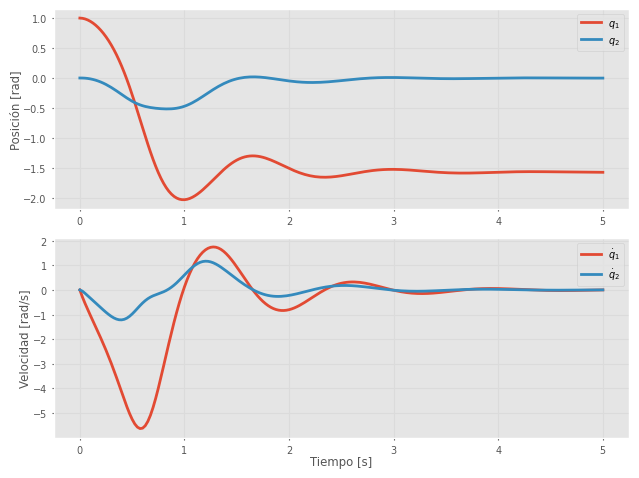

In [198]:
# Parámetros de la simulación
Ts = 0.025
# Estado inicial del doble péndulo
x0 = np.array([1,0,0,0])
t_span = [0, 5]
# Armo la base de tiempo para las muestras
t = np.arange(t_span[0], t_span[1]+Ts, Ts)

# Ejemplo: torques nulos
def tau_zero(t, y):
    return np.r_[0,0]

sol = solve_ivp(dxdt, t_span, x0, args=(tau_zero,), max_step=0.01, t_eval=t)
q = sol.y[0:2,:].T
qp = sol.y[2:,:].T
dp_plot_curve(t,q,qp)

In [199]:
dp_animate(q,fkine_1,fkine_2,Ts=Ts,trail=True)

## Ejemplo 3: ecuaciones del movimiento de un péndulo sobre un carro



In [94]:
# Definición de los parámetros cinemáticos y dinámicos del robot
DH_params = {
    0: {'theta':0, 'alpha': -np.pi/2, 'a': 0, 'joint_type':'p'},  
    1: {'alpha': 0, 'd': 0, 'joint_type':'r'}   
}

dyn_params  = {
    0:{'Ioxy': 0, 'Ioxz': 0, 'Ioyz': 0, 'yg': 0, 'zg': 0},
    1:{'Ioxy': 0, 'Ioxz': 0, 'Ioyz': 0, 'yg': 0, 'zg': 0}
}

# Montaje
g_vec = sp.Matrix([9.81, 0, 0])


# Cálculo de la cinemática directa simbólica
print("Calculando cinemática directa ...")
A_list, W_list, q = fkine_symbolic(DH_params)
print("POSE(q)=")
sp.pretty_print(W_list[-1])
print("Variables articulares:", q)

# Cálculo de las matrices de la dinámica
print("Calculando las matrices de la dinámica ...")
M, C, G, q_p, q_2p = dynamics_lagrange(W_list, q, g_vec, dyn_params)


print("Matriz M:")
sp.pprint(M)
print("\nMatriz C:")
sp.pprint(C)
print("\nVector G:")
sp.pprint(G)



Calculando cinemática directa ...
POSE(q)=
⎡cos(q₂)   -sin(q₂)  0     a₂⋅cos(q₂)   ⎤
⎢                                       ⎥
⎢   0         0      1         0        ⎥
⎢                                       ⎥
⎢-sin(q₂)  -cos(q₂)  0  -a₂⋅sin(q₂) + q₁⎥
⎢                                       ⎥
⎣   0         0      0         1        ⎦
Variables articulares: (q1, q2)
Calculando las matrices de la dinámica ...
Calculando M ...
Calculando C ...
Calculando G ...
Matriz M:
⎡       m₁ + m₂             m₂⋅(-a₂ - xg₂)⋅cos(q₂)   ⎤
⎢                                                    ⎥
⎢                                  2                 ⎥
⎣m₂⋅(-a₂ - xg₂)⋅cos(q₂)  Iozz₂ + a₂ ⋅m₂ + 2⋅a₂⋅m₂⋅xg₂⎦

Matriz C:
⎡0  m₂⋅qp₂⋅(a₂ + xg₂)⋅sin(q₂)⎤
⎢                            ⎥
⎣0              0            ⎦

Vector G:
⎡            0            ⎤
⎢                         ⎥
⎢981⋅m₂⋅(a₂ + xg₂)⋅sin(q₂)⎥
⎢─────────────────────────⎥
⎣           100           ⎦


In [95]:
for j in range(2):
    for i in range(2):
        print(f'M[{i},{j}]=',M[i,j])

M[0,0]= m1 + m2
M[1,0]= m2*(-a2 - xg2)*cos(q2)
M[0,1]= m2*(-a2 - xg2)*cos(q2)
M[1,1]= Iozz2 + a2**2*m2 + 2*a2*m2*xg2


In [96]:
for j in range(2):
    for i in range(2):
        print(f'C[{i},{j}]=',C[i,j])


C[0,0]= 0
C[1,0]= 0
C[0,1]= m2*qp_2*(a2 + xg2)*sin(q2)
C[1,1]= 0


In [97]:
for i in range(2):
    print(f'G[{i}]=',G[i])

G[0]= 0
G[1]= 981*m2*(a2 + xg2)*sin(q2)/100
